In [1]:
# Standard Imports
import numpy as np
import random
import matplotlib.pyplot as plt

# Wavelet
import pywt

# Utils
from config import *
from utils.display import loadAndDisplay, getTemporalSignals
from utils.wavelet import applyAndCompareWTMethods

In [2]:
norm_fmri_dict = loadAndDisplay(FMRI_NORM_PATH, "FMRI NORMALIZED", print_summary = True)


INFORMATION ABOUT FMRI NORMALIZED NIFTI FILE:

----------------------------------------------------------------------------------------------------
Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (91, 109, 91, 200)
Dimensions of the NIfTI image: [  4  91 109  91]
Dimensions of NIfTI img data: (91, 109, 91, 200)
Voxel size (mm): (2.0, 2.0, 2.0, 3.56)


## IMPORTANT

In this part of the project we are using the Wavelet to analyze 1D temporal signals. The Wavelet function implemented by the PYWT library requests in input the scale parameter, corresponding to the values for which to scale the Mother Wavelet, used to extract details from the 1D signal. It's important to give values of lower that are greater than the Niquist Limit otherwise the Wavelet will search for details that are not feasible.
- TR = 3.56 s ---> I'm getting data at a frequency of 0.28 Hz --> Nyquist Limit = 0.14 Hz --> I cannot capture with the Wavelet events that happen more than 0.14 times per second
- I can use scale ranges from 0.01 to 0.1

### Here I extract an arbitrary number of temporal signals from time_series
Extraction of 5 representative signals

In [16]:
time_series = np.load("data/part3/time_series.npy")
signals_dict = getTemporalSignals(time_series, count=5, idxs=[24,26,61,80,135])

# 61 = 7Networks_LH_Cont_Par_1, poli opposti ICA
# 135 = 7Networks_LH_Cont_Par_1
# 24 e 26 = best correlation 0.99
# 80 = best network PC1

signals = [mat for mat in signals_dict.values()]

In [10]:
regions_names = list(signals_dict.keys())
regions_names

['7Networks_LH_SomMot_10 (idx 24)',
 '7Networks_LH_SomMot_12 (idx 26)',
 '7Networks_LH_Cont_Par_1 (idx 61)',
 '7Networks_LH_Default_Par_2 (idx 80)',
 '7Networks_RH_DorsAttn_Post_1 (idx 135)']

### Some usefull documentation: https://pywavelets.readthedocs.io/en/latest/ref/cwt.html

- scalesarray_like
    The wavelet scales to use. One can use f = scale2frequency(wavelet, scale)/sampling_period to determine what physical frequency, f. Here, f is in hertz when the sampling_period is given in seconds.

- example: scales = np.logspace(np.log10(1), np.log10(128), 128)

- Type of wavelets (the formula change): mexican hat, morlet, complex morlet, gaussian derivative, shannon

- cmorlet is the only complex wave, the other ones are real wave (just one sinusoidal function used) --> vertical lines are there because at a certain point the wavelet is 0 due to its oscilattions and so multiplying the signal by 0 gives zero energy


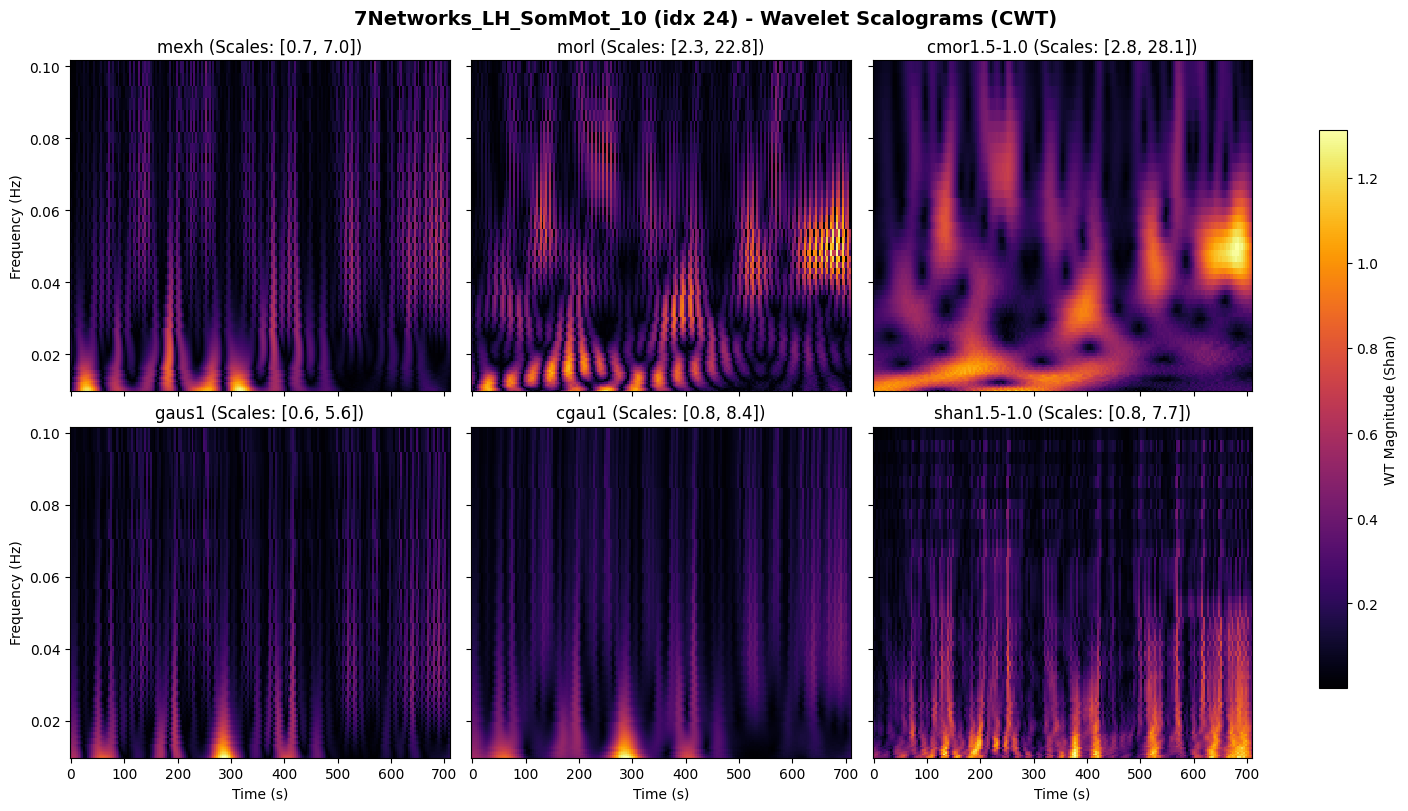

In [17]:
TR = 3.56 # Time Period
freqs_range = [0.01, 0.1]

applyAndCompareWTMethods(signals[0], TR, freqs_range, regions_names[0])

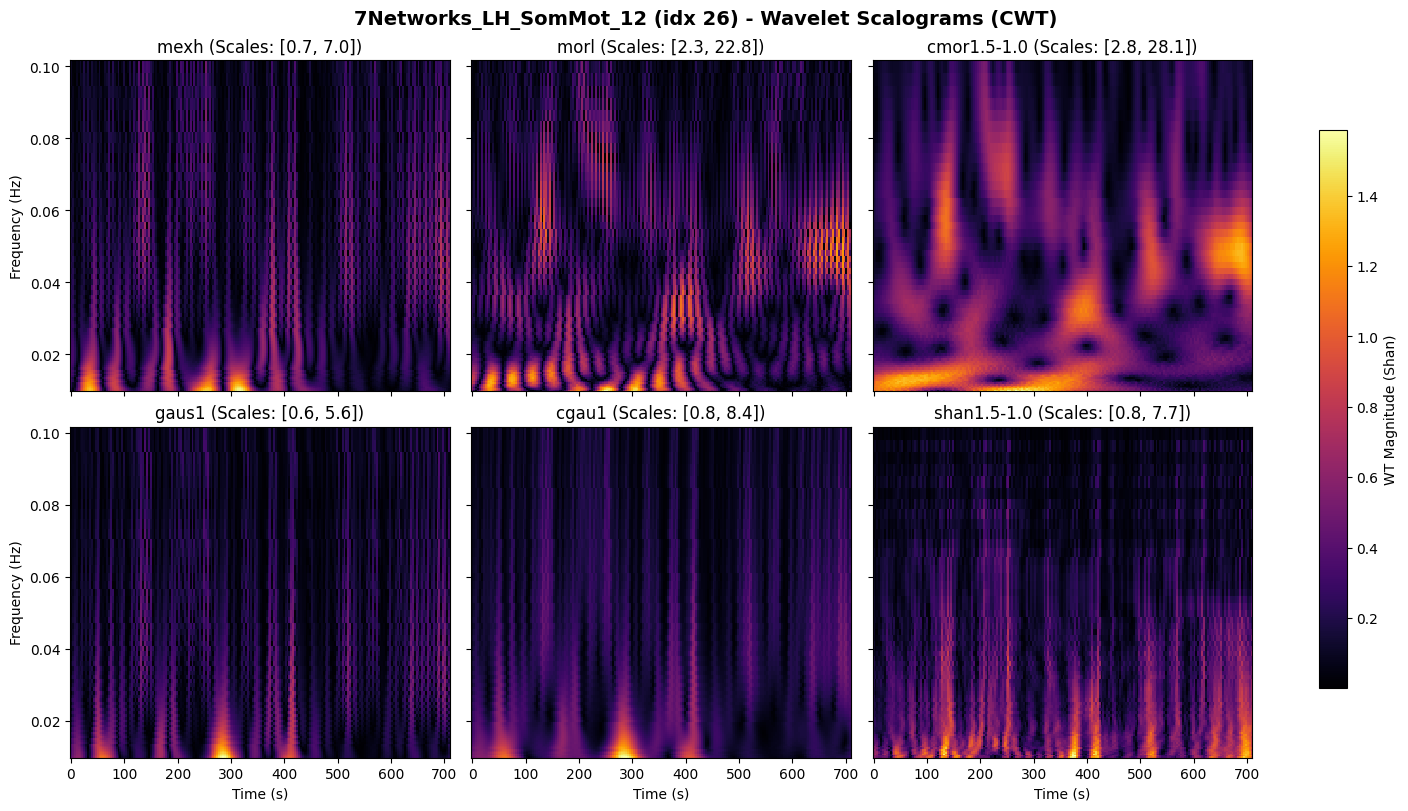

In [18]:
applyAndCompareWTMethods(signals[1], TR, freqs_range, regions_names[1])

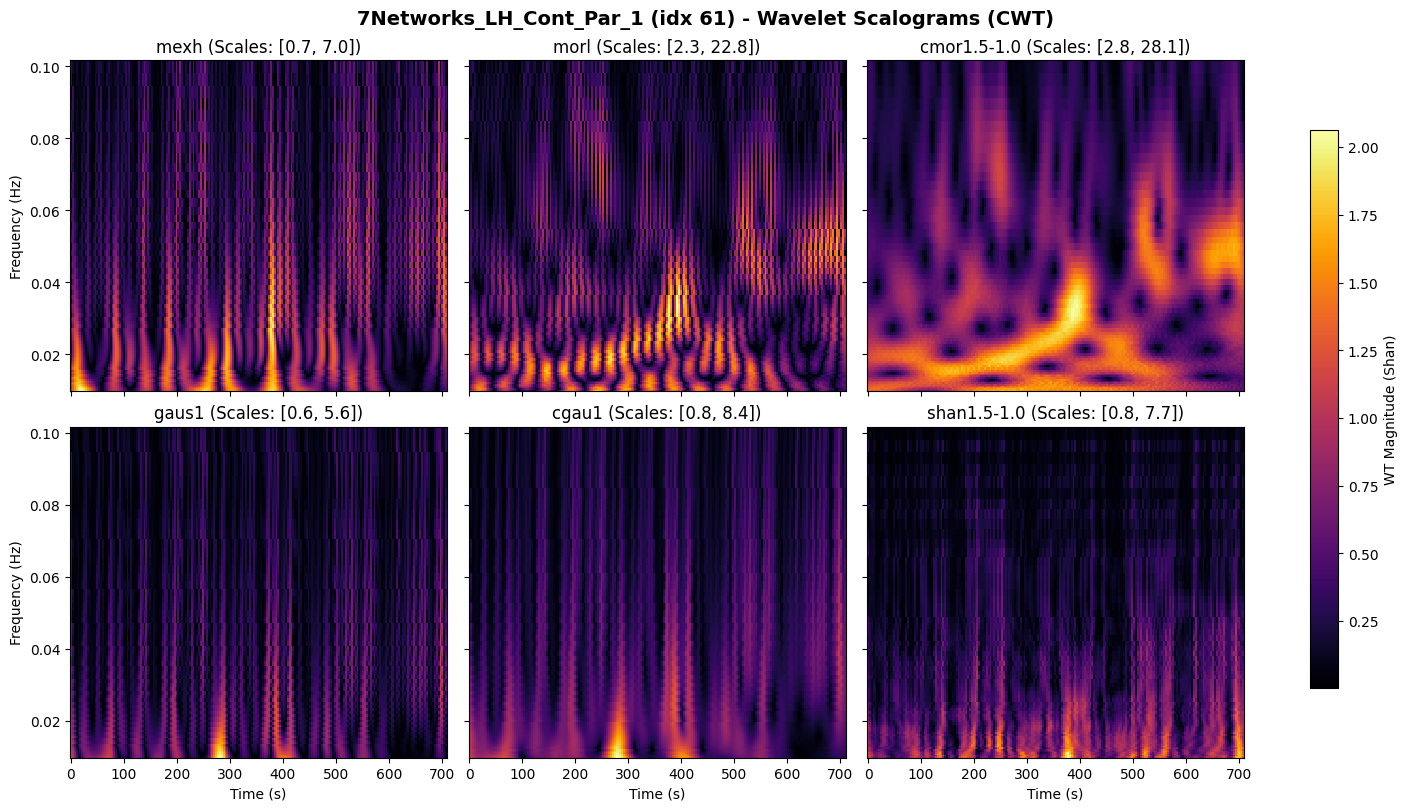

In [19]:
applyAndCompareWTMethods(signals[2], TR, freqs_range, regions_names[2])

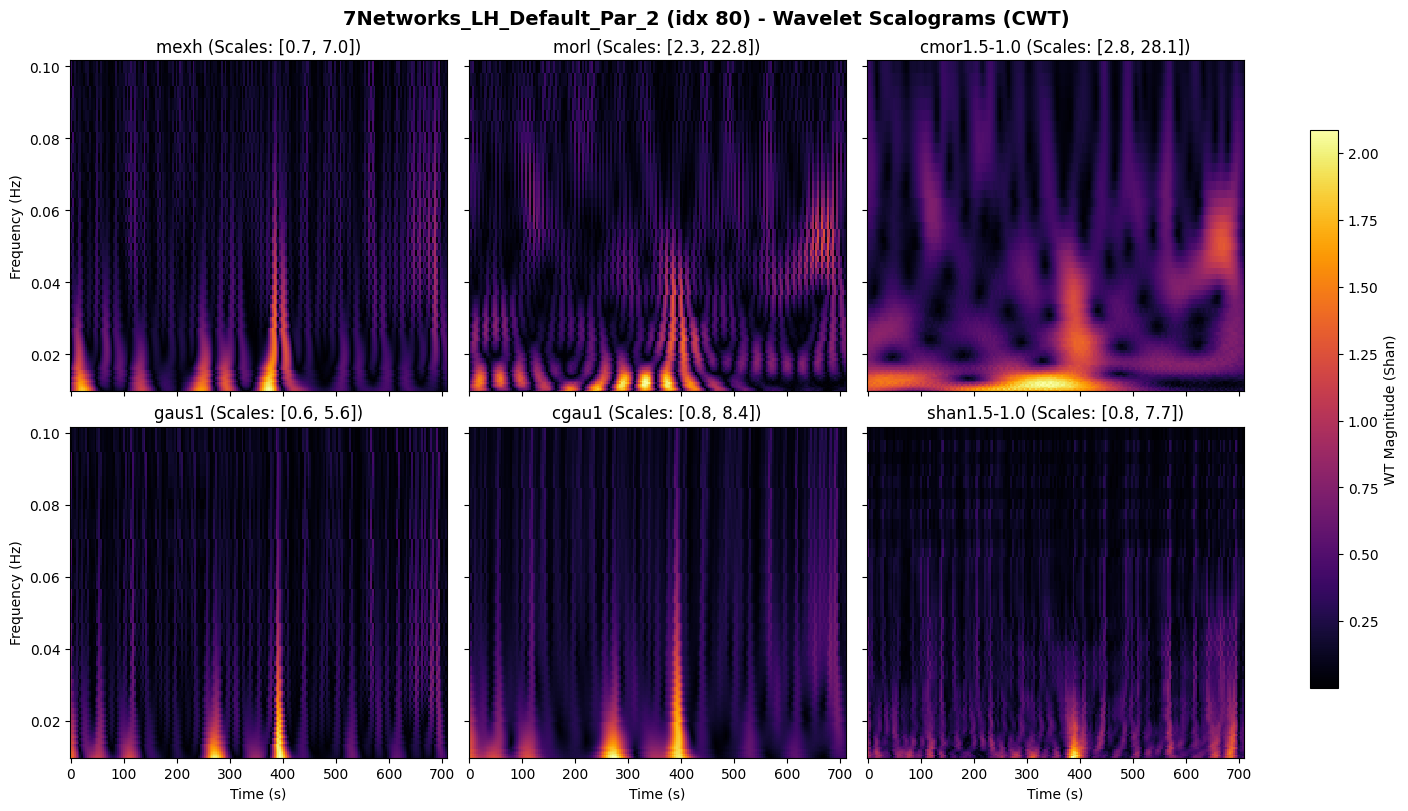

In [20]:
applyAndCompareWTMethods(signals[3], TR, freqs_range, regions_names[3])

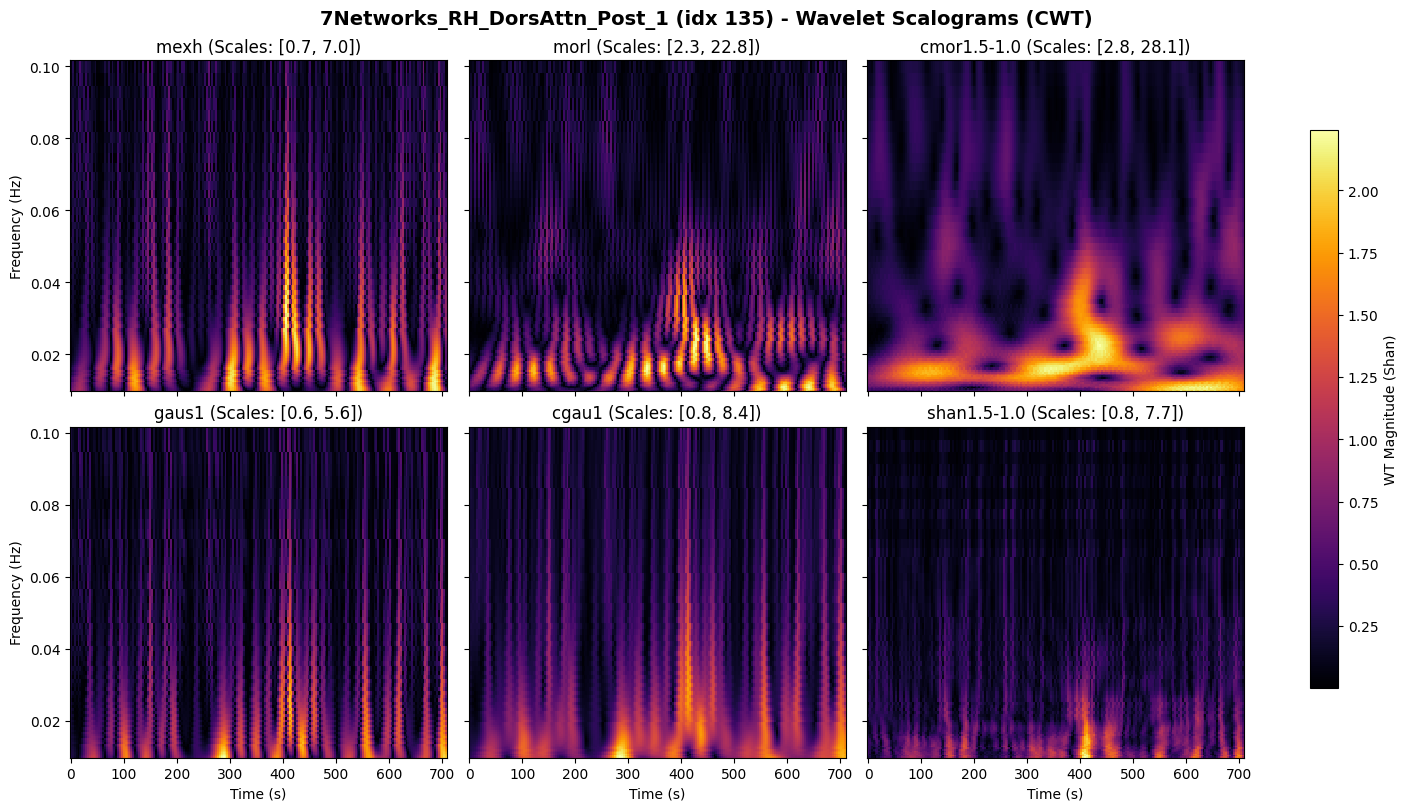

In [24]:
applyAndCompareWTMethods(signals[4], TR, freqs_range, regions_names[4])

## Conclusions

1) Similar Areas --> highest correlation: the plots of these two areas are really similar. They light up with the same magnitude and at the same time instants, they confirm their synchronization given by the similarity measures

2) Opposite areas ICA: the plots measure the magnitude of the signal, despite the sign being negative or positive. So from the plots it seems that they are of the same strenght and synchronized but in reality, when one of them light up, the other one does the same but in the opposite direction

3) Default Mode Network dynamic: lighting up at low frequency for many time instants, no spikes at high frequency. So the underlined brain activity is represented by a wave of very low frequency but at high energy